In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
pd.set_option('display.max_columns', None)

DATA_DIR ="../data/raw/"

customers = pd.read_csv(DATA_DIR + "olist_customers_dataset.csv")
orders = pd.read_csv(DATA_DIR + "olist_orders_dataset.csv")
order_items = pd.read_csv(DATA_DIR + "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_DIR + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_DIR + "olist_order_reviews_dataset.csv")
products = pd.read_csv(DATA_DIR + "olist_products_dataset.csv")
category_translation = pd.read_csv(DATA_DIR + "product_category_name_translation.csv")


for name, df in [("customers",customers),("orders",orders),("order_item",order_items)]:
    print(name,df.shape)

customers (99441, 5)
orders (99441, 8)
order_item (112650, 7)


In [7]:
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])
    print(orders['order_purchase_timestamp'].min(), "to", orders['order_purchase_timestamp'].max())

2016-09-04 21:15:19 to 2018-10-17 17:30:18
2016-09-04 21:15:19 to 2018-10-17 17:30:18
2016-09-04 21:15:19 to 2018-10-17 17:30:18
2016-09-04 21:15:19 to 2018-10-17 17:30:18


**Merge into one master transaction table:**


In [8]:
df = orders.merge(customers, on='customer_id', how='left')
df = df.merge(order_items, on='order_id', how='left')
df = df.merge(payments, on='order_id', how='left')
df = df.merge(products, on='product_id', how='left')
df = df.merge(category_translation, on='product_category_name', how='left')

# Keep only delivered orders for the core analysis (document this decision in your README)
df = df[df['order_status'] == 'delivered'].copy()

print(df.shape)
df.head()

(115038, 31)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1.0,credit_card,1.0,18.12,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3.0,voucher,1.0,2.00,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2.0,voucher,1.0,18.59,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,1.0,boleto,1.0,141.46,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,1.0,credit_card,3.0,179.12,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto


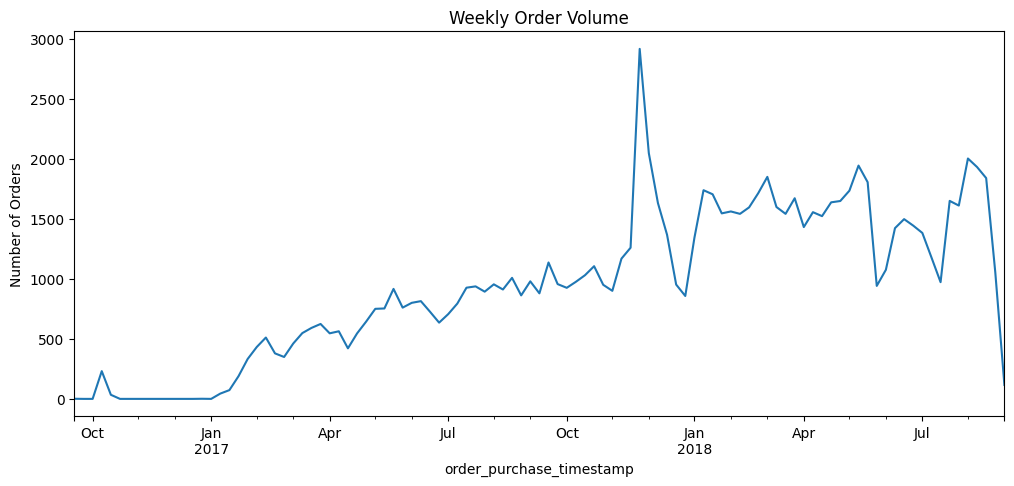

In [9]:
plt.figure(figsize=(12,5))
df.set_index('order_purchase_timestamp').resample('W')['order_id'].nunique().plot()
plt.title("Weekly Order Volume")
plt.ylabel("Number of Orders")
plt.show()

In [10]:
df.to_csv("../data/processed/master_transactions.csv", index=False)

Feature engineering (
move to 
notebooks/02_feature_engineering.ipynb , then
src/features.py )

In [11]:
customers_full = orders.merge(customers, on='customer_id', how='left')
# customer-level aggregation
customer_orders = customers_full.groupby('customer_unique_id').agg(
first_order_date=('order_purchase_timestamp', 'min'),
last_order_date=('order_purchase_timestamp', 'max'),
n_orders=('order_id', 'nunique')
).reset_index()
customer_orders['customer_lifetime_days'] = (
customer_orders['last_order_date']-customer_orders['first_order_date']
).dt.days

In [15]:
if 'review_score' not in df.columns:
    df = df.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

agg_dict = {
    'total_spend': ('payment_value', 'sum'),
    'avg_order_value': ('payment_value', 'mean'),
    'n_items': ('order_item_id', 'count'),
    'n_distinct_categories': ('product_category_name_english', 'nunique'),
    'avg_review_score': ('review_score', 'mean'),
}

order_value = df.groupby('customer_unique_id').agg(**agg_dict).reset_index()

features = customer_orders.merge(order_value, on='customer_unique_id', how='left')

In [16]:
target = df.groupby('customer_unique_id')['payment_value'].sum().reset_index()
target.columns = ['customer_unique_id', 'clv_target']
data = features.merge(target, on='customer_unique_id', how='left')

In [17]:
# Customer is "active" if they've ordered again; else one-time buyer
data['is_repeat_customer'] = (data['n_orders'] > 1).astype(int)

In [18]:
df['delivery_days'] = (df['order_delivered_customer_date']- df['order_purchase_timestamp']).dt.days
delivery_speed = df.groupby('customer_unique_id')['delivery_days'].mean().reset_index()
data = data.merge(delivery_speed, on='customer_unique_id', how='left')

In [20]:
data.to_csv("../data/processed/model_features.csv", index=False)